# Geographic map of author affiliations
Reads `data/raw/icse_affiliations.json`, counts rows by country, and saves a choropleth to `figures/`.

In [1]:
# pip install geopandas matplotlib mapclassify

In [2]:
import json
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import pandas as pd
import geodatasets



## 1. Config — change these for a different conference

In [3]:
INPUT_FILE  = Path("../../data/raw/icse_affiliations.json")
OUTPUT_FILE = Path("figures/isce/icse_geo_map.png")
TITLE       = "ICSE (2010–2025)"
SUBTITLE    = "Author-institution rows by country"

# Optional: restrict to specific years. Set to None to include all.
YEARS = None          # e.g. [2020, 2021, 2022]

# Colormap — any matplotlib sequential cmap works: 'Blues', 'YlOrRd', 'Purples'…
CMAP = "Purples"

OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

## 2. Load & count

In [4]:
with open(INPUT_FILE) as f:
    records = json.load(f)

df = pd.DataFrame(records)
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["country_code"] = df["country_code"].str.upper().str.strip()

if YEARS:
    df = df[df["year"].isin(YEARS)]
    print(f"Filtered to {YEARS}: {len(df):,} rows")
else:
    print(f"All years: {len(df):,} rows")

counts = (
    df.dropna(subset=["country_code"])
    .groupby("country_code")
    .size()
    .reset_index(name="count")
)

total = counts["count"].sum()
counts["pct"] = (counts["count"] / total * 100).round(1)
counts.sort_values("count", ascending=False).head(10)

All years: 11,588 rows


,country_code,count,pct
62,US,3481,31.3
11,CN,2437,21.9
8,CA,680,6.1
14,DE,606,5.5
21,GB,473,4.3
3,AU,409,3.7
55,SG,370,3.3
32,IT,360,3.2
9,CH,330,3.0
24,HK,203,1.8


## 3. Load world geometry & merge

In [5]:
# naturalearth_lowres is bundled with geopandas — no download needed
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

world = world.rename(columns={"ADM0_A3": "iso_a3"})[["iso_a3", "geometry"]]

# naturalearth_lowres uses ISO alpha-3 in 'iso_a3'; OpenAlex returns alpha-2.
# We use pycountry (or a manual map) to bridge them.
# geopandas also exposes 'continent' and 'name' — we join on iso_a3 via a lookup.

# Build alpha-2 → alpha-3 lookup using the iso3166 data bundled in geopandas
try:
    import pycountry
    def a2_to_a3(a2):
        try:
            return pycountry.countries.get(alpha_2=a2).alpha_3
        except Exception:
            return None
    counts["iso_a3"] = counts["country_code"].apply(a2_to_a3)

except ImportError:
    # fallback: manual lookup for the most common research countries
    A2_TO_A3 = {
        "AF":"AFG","AL":"ALB","DZ":"DZA","AO":"AGO","AR":"ARG","AM":"ARM",
        "AU":"AUS","AT":"AUT","AZ":"AZE","BE":"BEL","BR":"BRA","BG":"BGR",
        "CA":"CAN","CL":"CHL","CN":"CHN","CO":"COL","HR":"HRV","CZ":"CZE",
        "DK":"DNK","EG":"EGY","EE":"EST","FI":"FIN","FR":"FRA","DE":"DEU",
        "GR":"GRC","HU":"HUN","IN":"IND","ID":"IDN","IR":"IRN","IE":"IRL",
        "IL":"ISR","IT":"ITA","JP":"JPN","KZ":"KAZ","KE":"KEN","KR":"KOR",
        "LV":"LVA","LT":"LTU","MX":"MEX","NL":"NLD","NZ":"NZL","NG":"NGA",
        "NO":"NOR","PK":"PAK","PE":"PER","PH":"PHL","PL":"POL","PT":"PRT",
        "RO":"ROU","RU":"RUS","SA":"SAU","RS":"SRB","SG":"SGP","SK":"SVK",
        "SI":"SVN","ZA":"ZAF","ES":"ESP","SE":"SWE","CH":"CHE","TW":"TWN",
        "TR":"TUR","UA":"UKR","GB":"GBR","US":"USA","UY":"URY","VN":"VNM",
    }
    counts["iso_a3"] = counts["country_code"].map(A2_TO_A3)
    print("pycountry not found — using built-in alpha-2→3 lookup.")
    print("  pip install pycountry  for full coverage.")

unmatched = counts[counts["iso_a3"].isna()]["country_code"].tolist()
if unmatched:
    print(f"  Could not map to alpha-3: {unmatched}")

world = world.merge(counts[["iso_a3", "count"]], on="iso_a3", how="left")
print(f"Matched {counts['iso_a3'].notna().sum()} / {len(counts)} countries onto world geometry")

Matched 66 / 66 countries onto world geometry


## 4. Plot & save

Saved → figures/isce/icse_geo_map.png


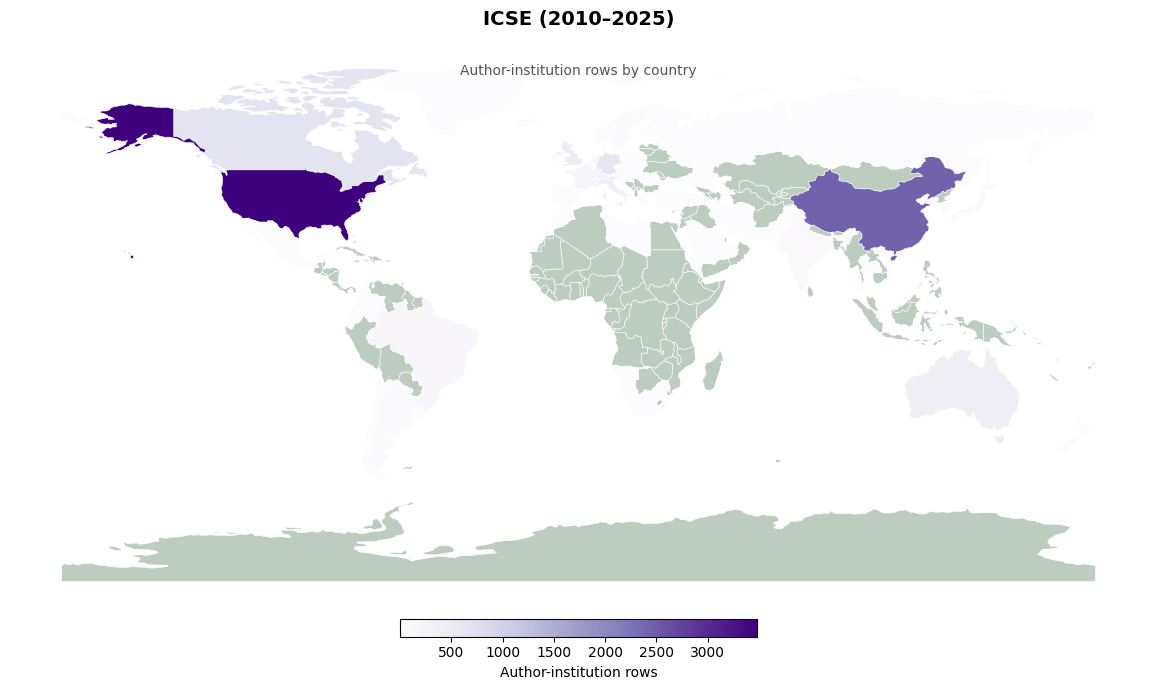

In [6]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f0f4f8")

# countries with no data
world[world["count"].isna()].plot(
    ax=ax,
    color="#bccdc0",
    edgecolor="white",
    linewidth=0.4,
)

# countries with data — choropleth
world[world["count"].notna()].plot(
    column="count",
    ax=ax,
    cmap=CMAP,
    edgecolor="white",
    linewidth=0.4,
    legend=True,
    legend_kwds={
        "label": "Author-institution rows",
        "orientation": "horizontal",
        "fraction": 0.03,
        "pad": 0.02,
        "shrink": 0.5,
    },
)

ax.set_title(TITLE, fontsize=14, fontweight="bold", pad=12)
ax.text(
    0.5, 0.96, SUBTITLE,
    transform=ax.transAxes,
    ha="center", va="top",
    fontsize=10, color="#555",
)
ax.axis("off")

# annotate top-5 countries with count labels
top5 = counts.nlargest(5, "count")
top5_geo = world[world["iso_a3"].isin(top5["iso_a3"].dropna())].copy()
top5_geo = top5_geo.merge(counts[["iso_a3","count"]], on="iso_a3")


plt.tight_layout()
plt.savefig(OUTPUT_FILE, dpi=200, bbox_inches="tight", facecolor="white")
print(f"Saved → {OUTPUT_FILE}")
plt.show()